In [1]:
import pandas as pd

data = {
    "name": ["Alice","Bob","Charlie","Diana","Eve","Frank","Grace","Henry","Iris","Jack","Karen","Liam","Mia","Noah","Olivia"],
    "math": [88,42,75,95,38,60,55,82,70,30,65,48,91,58,78],
    "science": [92,55,70,98,42,65,48,79,74,35,60,52,94,62,75],
    "english": [76,48,80,91,50,72,44,85,68,40,70,44,88,55,82],
    "history": [80,50,68,89,45,58,52,77,65,28,62,55,92,60,70],
    "pe": [95,60,88,97,55,70,62,90,78,45,75,58,96,68,85],
    "attendance_pct": [92,65,85,98,58,78,60,88,80,50,72,62,95,70,84],
    "study_hours_per_day": [4.5,1.2,3.0,6.0,0.8,2.5,1.5,4.0,3.5,0.5,2.8,1.8,5.5,2.0,3.8],
    "passed": [1,0,1,1,0,1,0,1,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

# Save as CSV (optional but good)
df.to_csv("students.csv", index=False)

# Display
df.head()


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0



Training Accuracy: 1.0

Test Accuracy: 1.0

Test Set Predictions:
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


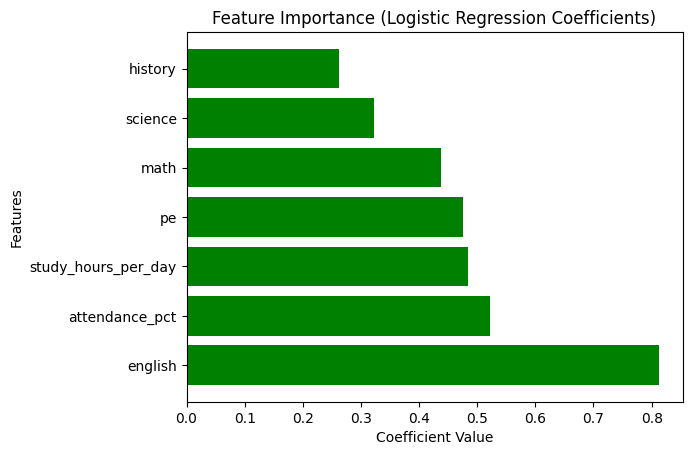


New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
###Task 4 — Machine Learning with scikit-learn

## Step 1 — Prepare Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features (exclude 'name' and target)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)

## Step 2 — Train Model
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train
model.fit(X_train_scaled, y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("\nTraining Accuracy:", train_acc)

## Step 3 — Evaluate Model
from sklearn.metrics import accuracy_score

# Predictions
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_acc)

# Detailed comparison
print("\nTest Set Predictions:")

test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")

## Step 4 — Feature Importance
import matplotlib.pyplot as plt
import numpy as np

# Get coefficients
coefficients = model.coef_[0]

# Pair with feature names
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value (important!)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

# Separate for plotting
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

# Colors: green (positive), red (negative)
colors = ['green' if v > 0 else 'red' for v in values]

# Plot
plt.figure()
plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()

## Step 5 — Predict New Student (Bonus)
# New student data (same order as features)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale using same scaler
new_student_scaled = scaler.transform(new_student)

# Prediction
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Prediction:", result)
print(f"Probability (Fail, Pass): {probability}")

# I sorted by absolute value to see the strongest influencing factors

